In [2]:
import sys
#!pip install polars --target ./my_custom_packages
#sys.path.append("./my_custom_packages") #
custom_path = "/stor/home/he4249/orange/my_custom_packages" # lifetimes, numpy<2.0.0, tslearn, scikit-learn-extra, dtaidistance
sys.path.insert(0, custom_path)

import polars as pl
import pandas as pd
import numpy as np

# Deprecated aliases back into NumPy so older libraries don't crash

np.long = int
np.ulong = int  
np.float = float # for lifetimes
np.bool = bool
np.object = object
np.int = int
np.unicode = str
np.str = str
np.complex = complex

import seaborn as sns
import matplotlib.pyplot as plt

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_period_transactions

from sklearn.metrics import mean_squared_error
from sklearn_extra.cluster import KMedoids

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

from tslearn.clustering import TimeSeriesKMeans
from tslearn.utils import to_time_series_dataset

from joblib import parallel_backend, Parallel, delayed


from tslearn.barycenters import dtw_barycenter_averaging
from dtaidistance import dtw


pl.Config.set_tbl_rows(50)
pl.Config(tbl_cols = 50)

In [15]:
df_merged = pl.read_parquet("df_merged.parquet")
display(df_merged.head())
display(df_merged.shape)

msisdn,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned
str,str,i64,date,str,str,f64,str,str,str,str,f64,f64,str,str,str,str,str
"""261320236812""","""1450-16867""",31,2026-05-05,"""Akama/Be Connect""","""akama up""",500.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.56831,-18.919853,"""4G+_TDD""","""Urbain""","""Densification""","""TanaAmbolokandrina""","""Analamanga"""
"""261320274396""","""2600-6926083""",31,2026-05-25,"""Akama/Be Connect""","""akama plus""",1000.0,"""APP OM""","""Atsinanana""","""Toamasina I""","""CU Toamasina""",49.387249,-18.15592,"""4G+_FDD""","""Urbain""","""Densification""","""TamaTanambao""","""Atsinanana"""
"""261320251199""","""3400-39723""",21,2026-05-07,"""Be""","""be 2000 new""",2000.0,"""IVR""","""Diana""","""Ambanja""","""Ambohimena""",48.354942,-13.558111,"""4G_FDD""","""Rural""","""Backbone et Couverture""","""AmbanjaAnkify""","""Diana"""
"""261320248283""","""1641-4359425""",45,2026-05-26,"""Akama/Be Connect""","""akama full""",2000.0,"""IVR""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.53292,-18.920139,"""5G""","""Urbain""","""Backbone et Couverture""","""TanaAndafiavaratra""","""Analamanga"""
"""261320454752""","""1651-4396547""",30,2026-05-06,"""Akama/Be Connect""","""akama up""",500.0,"""USSD""","""Analamanga""","""Antananarivo Atsimondrano""","""Ampanefy""",47.50986,-18.977667,"""4G+_FDD""","""Peri-Urbain""","""Couverture""","""TanaBevalala""","""Analamanga"""


(37976222, 18)

In [16]:
df_tsa = df_merged.sort("date").with_columns(
    (pl.col("date") - pl.col("date").shift(1).over("msisdn")).dt.total_days().alias("tblp_last"),
    (pl.col("date").shift(-1).over("msisdn") - pl.col("date")).dt.total_days().alias("tbnp_next")
)

df_tsa.head()

msisdn,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned,tblp_last,tbnp_next
str,str,i64,date,str,str,f64,str,str,str,str,f64,f64,str,str,str,str,str,i64,i64
"""261320418195""","""6030-60101""",55,2026-05-01,"""Be""","""be 1000 new""",1000.0,"""IVR""","""Atsimo Andrefana""","""Morombe""","""Ambahikily""",43.670109,-21.605024,"""4G_FDD""","""Rural""","""Couverture""","""Ambahikily""","""Atsimo-Andrefana""",null,9
"""261320258874""","""3620-9474051""",25,2026-05-01,"""Be""","""be 2000 new""",2000.0,"""USSD""","""Diana""","""Nosibe""","""Nosy be""",48.258389,-13.408195,"""5G""","""Urbain""","""Couverture""","""NosyBeLaVigie""","""Diana""",null,0
"""261320408103""","""3641-9485313""",10,2026-05-01,"""Akama/Be Connect""","""akama plus""",1000.0,"""USSD""","""Sava""","""Sambava""","""Sambava""",50.102238,-14.269185,"""4G+_FDD""","""Urbain""","""Couverture""","""SambavaSoavinandriana""","""Sava""",null,2
"""261320261406""","""3600-9497602""",32,2026-05-01,"""Be""","""be 500 new""",500.0,"""IVR""","""Diana""","""Ambilobe""","""Ambilobe""",49.054947,-13.19874,"""4G_FDD""","""Urbain""","""Densification""","""Ambilobe4""","""Diana""",null,0
"""261320207868""","""4000-43841""",26,2026-05-01,"""Be""","""be 1000 new""",1000.0,"""IVR""","""Boeny""","""Mitsinjo""","""Mitsinjo""",45.873058,-16.007694,"""4G_FDD""","""Rural""","""Couverture""","""Mitsinjo""","""Boeny""",null,4


In [6]:
display(df_tsa["tblp_last", "tbnp_next"].describe())

display(df_tsa.group_by("msisdn").agg(
    pl.col("tblp_last").mean().alias("avg_user_tbp"),
    pl.col("tblp_last").median().alias("median_user_tbp")
)["avg_user_tbp", "median_user_tbp"].describe())

df_tsa_pd = df_tsa.to_pandas()
# 500k users bought once and stopped. LOOK INTO IT.

statistic,tblp_last,tbnp_next
str,f64,f64
"""count""",3.510173e7,3.510173e7
"""null_count""",2.874492e6,2.874492e6
"""mean""",3.384222,3.384222
"""std""",5.943146,5.943146
"""min""",0.0,0.0
"""25%""",1.0,1.0
"""50%""",1.0,1.0
"""75%""",4.0,4.0
"""max""",79.0,79.0


statistic,avg_user_tbp,median_user_tbp
str,f64,f64
"""count""",2.347456e6,2.347456e6
"""null_count""",527036.0,527036.0
"""mean""",8.102995,6.737969
"""std""",9.246094,9.424316
"""min""",0.0,0.0
"""25%""",2.62963,2.0
"""50%""",5.111111,3.0
"""75%""",9.857143,7.5
"""max""",79.0,79.0


In [7]:
%%time
# 10% of data
df_sample = df_tsa_pd.sample(frac= 0.10, random_state = 4)

max_date = pd.to_datetime(df_sample["date"]).max()
split_date = max_date - pd.Timedelta(days = 20)

cal_holdout = calibration_and_holdout_data(
    df_sample, 
    customer_id_col = "msisdn", 
    datetime_col = "date",
    calibration_period_end = split_date,
    observation_period_end = max_date,
    monetary_value_col = "CA"
)

penalizers_to_test = [0.001, 0.01, 0.1, 1.0] # convergence error 0.0
best_penalizer = 0.0
best_mse = float("inf")

for pen in penalizers_to_test:
    bgf_tune = BetaGeoFitter(penalizer_coef = pen)
    
    bgf_tune.fit(
        cal_holdout["frequency_cal"], 
        cal_holdout["recency_cal"], 
        cal_holdout["T_cal"]
    )
    
    predicted_purchases = bgf_tune.predict(
        30, 
        cal_holdout["frequency_cal"], 
        cal_holdout["recency_cal"], 
        cal_holdout["T_cal"]
    )

    if predicted_purchases.isna().any():
        continue

    mse = mean_squared_error(cal_holdout["frequency_holdout"], predicted_purchases)
    
    if mse < best_mse:
        best_mse = mse
        best_penalizer = pen

display(best_penalizer)


/stor/home/he4249/orange/my_custom_packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/stor/home/he4249/orange/my_custom_packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


0.001

CPU times: user 1min 49s, sys: 8.17 s, total: 1min 57s
Wall time: 1min 57s


,coef,se(coef),lower 95% bound,upper 95% bound
r,0.790232,0.000762,0.788739,0.791725
alpha,5.012466,0.005992,5.000722,5.024211
a,0.037498,0.000130,0.037243,0.037752
b,0.708185,0.002474,0.703336,0.713035


/stor/home/he4249/orange/my_custom_packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,recency,T,monetary_value,predicted_purchases_for_next_t_days,prob_alive
msisdn,,,,,,
261320100056,9.0,70.0,77.0,500.000000,3.520896,0.989792
261320100081,0.0,0.0,75.0,0.000000,NaN,1.000000
261320100150,7.0,57.0,77.0,757.142857,2.697037,0.952986
261320100159,7.0,46.0,67.0,1000.000000,2.976311,0.924210
261320100167,16.0,52.0,55.0,978.125000,8.275230,0.994385


CPU times: user 5min 14s, sys: 8.73 s, total: 5min 23s
Wall time: 5min 23s


<Axes: title={'center': 'Frequency of Repeat Transactions'}, xlabel='Number of Calibration Period Transactions', ylabel='Customers'>

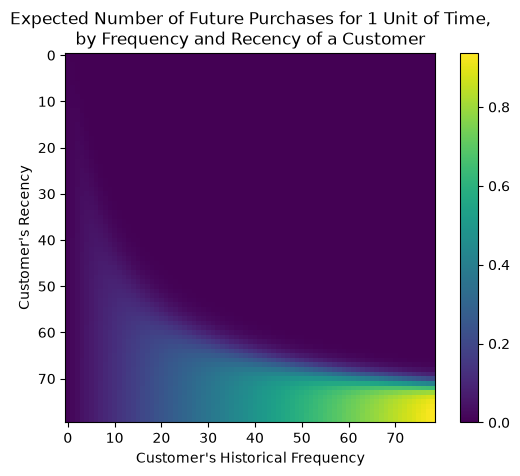

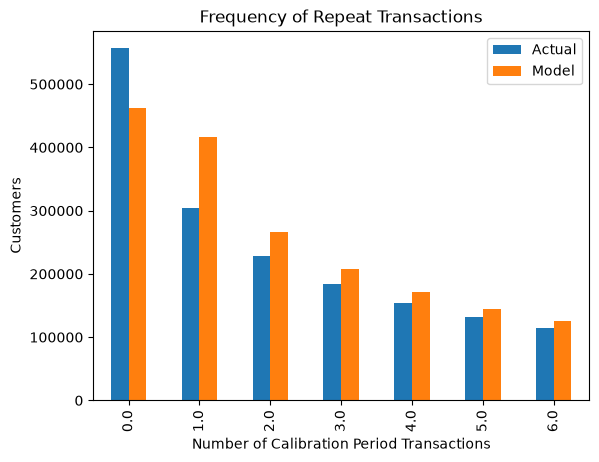

In [8]:
%%time 

best_penalizer = 0.01

rfm = summary_data_from_transaction_data(
    df_tsa_pd,
    customer_id_col = "msisdn",
    datetime_col = "date",
    monetary_value_col = "CA"
)
# T: Age, first purchase to end of period

bgf = BetaGeoFitter(penalizer_coef = best_penalizer)
bgf.fit(rfm["frequency"], rfm["recency"], rfm["T"])
display(bgf.summary)

t = 30 # Next 30 days
rfm["predicted_purchases_for_next_t_days"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t,
    rfm["frequency"],
    rfm["recency"],
    rfm["T"]
)

rfm["prob_alive"] = bgf.conditional_probability_alive(
    rfm["frequency"],
    rfm["recency"],
    rfm["T"]
)

display(rfm.head())

# expected purchases by recency and frequency
plot_frequency_recency_matrix(bgf)
# check model fit against actual data
plot_period_transactions(bgf)


count    2.874492e+06
mean     9.078334e-01
std      2.031014e-01
min      1.651640e-09
25%      9.424150e-01
50%      9.910506e-01
75%      9.985435e-01
max      1.000000e+00
Name: prob_alive, dtype: float64

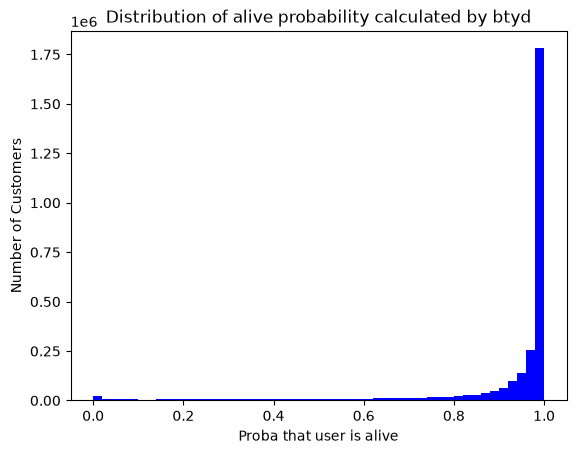

193709

81530

48879

In [9]:
display(rfm["prob_alive"].describe())
plt.hist(rfm["prob_alive"], bins = 50, color = "blue")
plt.title("Distribution of alive probability calculated by btyd")
plt.xlabel("Proba that user is alive")
plt.ylabel("Number of Customers")
plt.show()

display(sum(rfm["prob_alive"] < 0.5))
display(sum(rfm["prob_alive"] < 0.2))
display(sum(rfm["prob_alive"] < 0.1))

In [10]:
# Positve, gamma function requirement
g_summary = rfm[(rfm["frequency"] > 0) & (rfm["monetary_value"] > 0)]

ggf = GammaGammaFitter()
ggf.fit(g_summary["frequency"], g_summary["monetary_value"])

rfm["expected_average_monetary_value"] = ggf.conditional_expected_average_profit(
    rfm["frequency"], rfm["monetary_value"]
)

rfm["clv_12months"] = ggf.customer_lifetime_value(
    bgf,
    rfm["frequency"],
    rfm["recency"],
    rfm["T"],
    rfm["monetary_value"],
    time = 12,
    discount_rate  = 0.01 # Expected loss of value per month, about 13% annually: Professors Peter Fader and Bruce Hardie who developed the BG/NBD and Gamma-Gamma models used d = 0.01
            
    
)
rfm.head()


/stor/home/he4249/orange/my_custom_packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/stor/home/he4249/orange/my_custom_packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,recency,T,monetary_value,predicted_purchases_for_next_t_days,prob_alive,expected_average_monetary_value,clv_12months
msisdn,,,,,,,,
261320100056,9.0,70.0,77.0,500.000000,3.520896,0.989792,520.785105,19927.043159
261320100081,0.0,0.0,75.0,0.000000,NaN,1.000000,1058.129810,NaN
261320100150,7.0,57.0,77.0,757.142857,2.697037,0.952986,771.402629,22599.161338
261320100159,7.0,46.0,67.0,1000.000000,2.976311,0.924210,1002.753999,32344.071415
261320100167,16.0,52.0,55.0,978.125000,8.275230,0.994385,979.828687,87698.188814


In [11]:
%%time

user_plans = df_tsa.filter(pl.col("Nom du forfait").is_not_null()).sort(["msisdn", "date"]).group_by("msisdn").agg(
    pl.col("Nom du forfait").alias("purchase_sequence")
)["purchase_sequence"].to_list()

te = TransactionEncoder()
te_plans = te.fit_transform(user_plans)

df_plans_pd = pd.DataFrame(te_plans, columns = te.columns_)

# min_support: must appear in 1% of users
frequent_plans = fpgrowth(df_plans_pd, min_support = 0.01, use_colnames = True)

# min_threshold: min 20% confidence
# confidence: of all the people who bought A what percentage of them also bought B
rules = association_rules(frequent_plans, metric = "confidence", min_threshold = 0.20)

# 1 product leading to 1 product
nbo_rules = rules[
    (rules["antecedents"].apply(lambda x: len(x) == 1)) & 
    (rules["consequents"].apply(lambda x: len(x) == 1))
]

# Confidence: confidence of 0.65 means 65% of people who bought the antecedent went on to buy the consequent
# Lift: a lift of 3.5 means a user is 3.5 times more likely to buy Akama Up because they previously bought Be 500 New than a random user
nbo_rules = nbo_rules.sort_values(["antecedents", "lift"], ascending = [True, False])
best_rules = nbo_rules.drop_duplicates(subset = ["antecedents"], keep = "first")
best_rules["product_bought"] = best_rules["antecedents"].apply(lambda x: list(x)[0])
best_rules["likely_following_product"] = best_rules["consequents"].apply(lambda x: list(x)[0])

display(best_rules)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric,product_bought,likely_following_product
2102,frozenset({be 500}),frozenset({be 500 new}),0.485580,0.410969,0.279275,0.575136,1.399461,0.079716,1.386397,0.554877,be 500,be 500 new
4972,frozenset({akama go}),frozenset({akama go+}),0.091027,0.068749,0.041754,0.458700,6.672138,0.035496,1.720397,0.935257,akama go,akama go+
8013,frozenset({lany crédit 1 000 ar}),frozenset({lany crédit 500 ar}),0.111530,0.107125,0.047710,0.427780,3.993293,0.035763,1.560372,0.843675,lany crédit 1 000 ar,lany crédit 500 ar
3164,frozenset({be sms 1}),frozenset({be sms 7}),0.026433,0.291613,0.014913,0.564181,1.934688,0.007205,1.625414,0.496238,be sms 1,be sms 7
2980,frozenset({lany crédit 3 000 ar}),frozenset({akama full}),0.033161,0.057247,0.013062,0.393894,6.880607,0.011163,1.555427,0.883977,lany crédit 3 000 ar,akama full
2558,frozenset({be 2000 new}),frozenset({be 2000}),0.055164,0.068653,0.034869,0.632107,9.207296,0.031082,2.531573,0.943434,be 2000 new,be 2000
2557,frozenset({be 2000}),frozenset({be 2000 new}),0.068653,0.055164,0.034869,0.507910,9.207296,0.031082,1.920048,0.957098,be 2000,be 2000 new
1997,frozenset({akama al 1go}),frozenset({akama plus}),0.012860,0.287821,0.010458,0.813207,2.825389,0.006756,3.812658,0.654483,akama al 1go,akama plus
1993,frozenset({akama flash}),frozenset({akama up}),0.017263,0.255085,0.013186,0.763835,2.994433,0.008782,3.154209,0.677747,akama flash,akama up
4973,frozenset({akama go+}),frozenset({akama go}),0.068749,0.091027,0.041754,0.607347,6.672138,0.035496,2.314949,0.912882,akama go+,akama go


CPU times: user 1min 50s, sys: 37.1 s, total: 2min 27s
Wall time: 31.5 s


In [12]:
# last plan purchased
last_plans = df_tsa.filter(pl.col("Nom du forfait").is_not_null()).sort("date").group_by("msisdn").agg(
    pl.col("Nom du forfait").last().alias("last_plan_bought")
    ).to_pandas()

customer_profile = rfm.merge(last_plans, on = "msisdn", how = "left")

# Map next best offer
nbo_map = best_rules.set_index("product_bought")["likely_following_product"].to_dict()
customer_profile["next_best_offer"] = customer_profile["last_plan_bought"].map(nbo_map)

# Fill missing with personal most popular package
top_default_plan = df_merged["Nom du forfait"].mode()[0]
customer_profile["next_best_offer"] = customer_profile["next_best_offer"].fillna(top_default_plan)

display(customer_profile.head())


,msisdn,frequency,recency,T,monetary_value,predicted_purchases_for_next_t_days,prob_alive,expected_average_monetary_value,clv_12months,last_plan_bought,next_best_offer
0,261320100056,9.0,70.0,77.0,500.000000,3.520896,0.989792,520.785105,19927.043159,be 500,be 500 new
1,261320100081,0.0,0.0,75.0,0.000000,NaN,1.000000,1058.129810,NaN,be 500 new,be 500
2,261320100150,7.0,57.0,77.0,757.142857,2.697037,0.952986,771.402629,22599.161338,ao tsara 90,be 1000 new
3,261320100159,7.0,46.0,67.0,1000.000000,2.976311,0.924210,1002.753999,32344.071415,be 1000,be 1000 new
4,261320100167,16.0,52.0,55.0,978.125000,8.275230,0.994385,979.828687,87698.188814,akama up,akama go+


In [13]:
def person_bucket(row):
    # Active and high predicted transactions
    if row["prob_alive"] > 0.7 and row["predicted_purchases_for_next_t_days"] > 6.0:
        return "Upsell by next best offer"
    # Frequent but at risk of leaving
    elif 0.3 <= row["prob_alive"] <= 0.7:
        return "Reengagement by discount"
    # Churning
    elif row["prob_alive"] < 0.3:
        return "Win back"
    else:
        return "Standard"

customer_profile["marketing_segment"] = customer_profile.apply(person_bucket, axis = 1)
display(customer_profile.head())
display(customer_profile["marketing_segment"].value_counts())

,msisdn,frequency,recency,T,monetary_value,predicted_purchases_for_next_t_days,prob_alive,expected_average_monetary_value,clv_12months,last_plan_bought,next_best_offer,marketing_segment
0,261320100056,9.0,70.0,77.0,500.000000,3.520896,0.989792,520.785105,19927.043159,be 500,be 500 new,Standard
1,261320100081,0.0,0.0,75.0,0.000000,NaN,1.000000,1058.129810,NaN,be 500 new,be 500,Standard
2,261320100150,7.0,57.0,77.0,757.142857,2.697037,0.952986,771.402629,22599.161338,ao tsara 90,be 1000 new,Standard
3,261320100159,7.0,46.0,67.0,1000.000000,2.976311,0.924210,1002.753999,32344.071415,be 1000,be 1000 new,Standard
4,261320100167,16.0,52.0,55.0,978.125000,8.275230,0.994385,979.828687,87698.188814,akama up,akama go+,Upsell by next best offer


marketing_segment
Standard                     1927486
Upsell by next best offer     653293
Reengagement by discount      175014
Win back                      118699
Name: count, dtype: int64

In [14]:
# One time buyers in three months, why?

max_date = df_tsa["date"].max()

user_summary = df_tsa.sort("date").group_by("msisdn").agg(
    pl.len().alias("purchase_count"),
    pl.col("date").min().alias("first_date"),
    pl.col("Nom du forfait").first().alias("plan_bought"),
    pl.col("CA").sum().alias("total_spent")
)

one_timers = user_summary.filter(pl.col("purchase_count") == 1)
display(f"n one timers: {len(one_timers)}")

plan_tendencies = (
    user_summary.group_by("plan_bought")
    .agg(
        pl.len().alias("total_buyers"),
        (pl.col("purchase_count") == 1).sum().alias("one_time_buyers"),
        # Avg days since purchase for one-timers (tells you if they are lost vs. brand new)
        (max_date - pl.col("first_date")).filter(pl.col("purchase_count") == 1).dt.total_days().mean().round(1).alias("avg_days_ago")
    )
    .with_columns(
        (pl.col("one_time_buyers") / pl.col("total_buyers") * 100).round(2).alias("onetimers_rate")
    )
    .filter(pl.col("total_buyers") > 10000)  # low volume noise
    .sort("onetimers_rate", descending = True)
)

display(plan_tendencies)

'n one timers: 527036'

plan_bought,total_buyers,one_time_buyers,avg_days_ago,onetimers_rate
str,u32,u32,f64,f64
"""ao tsara""",11787,6918,45.1,58.69
"""be 500""",231094,110424,23.5,47.78
"""be 1000""",180214,71286,21.9,39.56
"""akama up""",231884,60824,45.7,26.23
"""ao tsara 90""",55745,9547,36.1,17.13
"""be sms 1""",14067,2354,42.3,16.73
"""be connect 450mo""",16112,2497,41.0,15.5
"""be 500 new""",646173,95568,64.0,14.79
"""be 10000 new""",11894,1455,63.8,12.23


In [15]:
segment_financials = customer_profile.groupby("marketing_segment").agg(
    user_count = ("msisdn", "count"),
    total_clv_12months = ("clv_12months", "sum"),
    avg_clv_12months = ("clv_12months", "mean")
).reset_index()

segment_financials["total_clv_billion"] = (segment_financials["total_clv_12months"] / 1_000_000_000).round(2)
segment_financials = segment_financials.sort_values("total_clv_billion", ascending = False)

display(segment_financials[["marketing_segment", "user_count", "total_clv_billion", "avg_clv_12months"]])

,marketing_segment,user_count,total_clv_billion,avg_clv_12months
2,Upsell by next best offer,653293,98.02,150047.506097
1,Standard,1927486,48.49,35371.714242
0,Reengagement by discount,175014,2.41,13742.405570
3,Win back,118699,0.41,3421.554898


In [16]:
df_datatech_region = df_tsa.sort("date").group_by("msisdn").agg(
    pl.col("region_cleaned").last(),
    pl.col("Typologie").last(),
    pl.col("Max_RAT").last()
).to_pandas()

customer_profile_full = customer_profile.merge(df_datatech_region, on = "msisdn", how = "left")

more_user_info = customer_profile_full.groupby(["Max_RAT", "Typologie"]).agg(
    n_user = ("msisdn", "count"),
    avg_prob_alive = ("prob_alive", "mean"),
    avg_clv_12months = ("clv_12months", "mean")
).reset_index().sort_values("avg_clv_12months", ascending = False)

display(more_user_info)

# Which regions have the highest concentration of churning users
region_churn = customer_profile_full[customer_profile_full["marketing_segment"] == "Win back"]
region_churn_stats = region_churn.groupby("region_cleaned").size().sort_values(ascending=False)
display(region_churn_stats / len(region_churn) )

,Max_RAT,Typologie,n_user,avg_prob_alive,avg_clv_12months
16,5G,Urbain,206550,0.911524,106154.112447
15,5G,Peri-Urbain,47121,0.901644,103941.928843
7,4G+_TDD,Peri-Urbain,59527,0.895283,100352.405123
4,4G+_FDD,Peri-Urbain,60222,0.901351,99664.535510
9,4G+_TDD,Urbain,267736,0.907462,92182.403532
6,4G+_FDD,Urbain,427014,0.913919,86298.779148
8,4G+_TDD,Rural,1471,0.895029,82602.565402
14,4G_TDD,Urbain,6746,0.903906,73740.716038
5,4G+_FDD,Rural,16716,0.916137,70414.403999
12,4G_FDD,Urbain,380665,0.910868,66196.163737


region_cleaned
Diana                  0.182318
Analamanga             0.179041
Sava                   0.125309
Boeny                  0.113236
Atsimo-Andrefana       0.092815
Atsinanana             0.061643
Sofia                  0.047347
Menabe                 0.040902
Analanjirofo           0.032688
Melaky                 0.022376
Betsiboka              0.018197
Vakinankaratra         0.014920
Alaotra-Mangoro        0.012974
Vatovavy Fitovinany    0.009899
Haute matsiatra        0.009596
Anosy                  0.007582
Androy                 0.007574
Atsimo-Atsinana        0.007287
Itasy                  0.004305
Ihorombe               0.004229
Amoron'i mania         0.002974
Bongolava              0.002789
dtype: float64

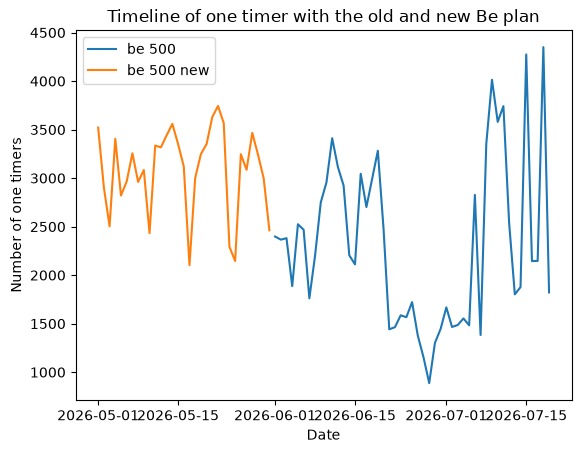

In [17]:
legacy_vs_new = one_timers.filter(
    pl.col("plan_bought").is_in(["be 500", "be 500 new"])
).to_pandas()

for plan in ["be 500", "be 500 new"]:
    subset = legacy_vs_new[legacy_vs_new["plan_bought"] == plan]
    subset["first_date"].dt.date.value_counts().sort_index().plot(label = plan)

plt.title("Timeline of one timer with the old and new Be plan")
plt.ylabel("Number of one timers")
plt.xlabel("Date")
plt.legend()
plt.show()

In [18]:
plan_prices = df_tsa_pd.drop_duplicates(subset = ["Nom du forfait"])[["Nom du forfait", "CA"]].set_index("Nom du forfait")["CA"].to_dict()

upsell_segment = customer_profile[customer_profile["marketing_segment"] == "Upsell by next best offer"]
upsell_segment["last_plan_price"] = upsell_segment["last_plan_bought"].map(plan_prices)
upsell_segment["nbo_price"] = upsell_segment["next_best_offer"].map(plan_prices)

# price difference
upsell_segment["price_diff"] = upsell_segment["nbo_price"] - upsell_segment["last_plan_price"]

def categorize_upsell(diff):
    if diff > 0:
        return "+ revenue"
    elif diff == 0:
        return "Retention"
    else:
        return "- revenue"

upsell_segment["nbo_revenue"] = upsell_segment["price_diff"].apply(categorize_upsell)

display(upsell_segment["nbo_revenue"].value_counts())

nbo_revenue
Retention    282542
- revenue    277988
+ revenue     92763
Name: count, dtype: int64

In [19]:
best_rules["antecedent_price"] = best_rules["product_bought"].map(plan_prices)
best_rules["consequent_price"] = best_rules["likely_following_product"].map(plan_prices)

profitable_rules = best_rules[best_rules["consequent_price"] >= best_rules["antecedent_price"]]

profitable_nbo_map = profitable_rules.set_index("product_bought")["likely_following_product"].to_dict()

# Remap NBO for customer profile
customer_profile["next_best_offer_safe"] = customer_profile["last_plan_bought"].map(profitable_nbo_map)

# default to the overall top plan
customer_profile["next_best_offer_safe"] = customer_profile["next_best_offer_safe"].fillna(top_default_plan)

upsell_segment_2 = customer_profile[customer_profile["marketing_segment"] == "Upsell by next best offer"]
upsell_segment_2["last_plan_price"] = upsell_segment_2["last_plan_bought"].map(plan_prices)
upsell_segment_2["nbo_safe_price"] = upsell_segment_2["next_best_offer_safe"].map(plan_prices)
upsell_segment_2["price_diff_safe"] = upsell_segment_2["nbo_safe_price"] - upsell_segment_2["last_plan_price"]

upsell_segment_2["nbo_revenue_safe"] = upsell_segment_2["price_diff_safe"].apply(categorize_upsell)

display(upsell_segment_2["nbo_revenue_safe"].value_counts())

nbo_revenue_safe
Retention    459412
+ revenue    159164
- revenue     34717
Name: count, dtype: int64

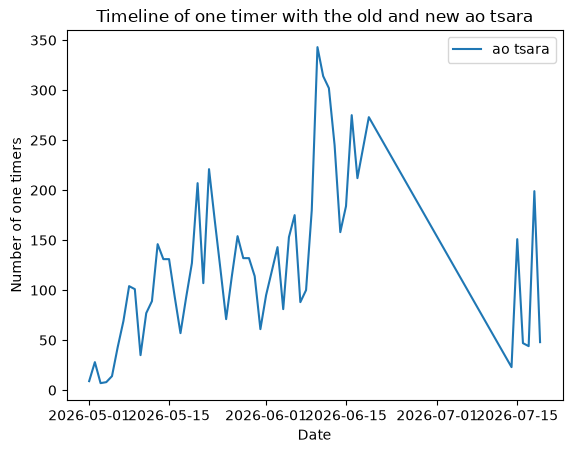

In [20]:
legacy_vs_new = one_timers.filter(
    pl.col("plan_bought").is_in(["ao tsara"])
).to_pandas()

for plan in ["ao tsara"]:
    subset = legacy_vs_new[legacy_vs_new["plan_bought"] == plan]
    subset["first_date"].dt.date.value_counts().sort_index().plot(label = plan)

plt.title("Timeline of one timer with the old and new ao tsara")
plt.ylabel("Number of one timers")
plt.xlabel("Date")
plt.legend()
plt.show()

In [27]:
df_ts = df_tsa.filter(df_tsa["msisdn"].is_in(rfm[rfm["prob_alive"] < 0.1].reset_index()["msisdn"]))
display(df_ts.head())
display(df_ts.shape)
display(df_ts.dtypes)
df_ts.write_parquet("df_ts.parquet")

msisdn,site_id,nb_jours,date,Gamme_groupe,Nom du forfait,CA,Group_canal,sig_region_name,sig_district_name,sig_commune_name,x,y,Max_RAT,Typologie,Typologie site,sig_nom_site,region_cleaned,tblp_last,tbnp_next
str,str,i64,date,str,str,f64,str,str,str,str,f64,f64,str,str,str,str,str,i64,i64
"""261320246020""","""4611-12033793""",14,2026-05-01,"""Akama/Be Connect""","""akama full""",2000.0,"""USSD""","""Boeny""","""Mahajanga I""","""Mahajanga I""",46.300919,-15.7155,"""5G""","""Urbain""","""Couverture""","""MajungaLaCorniche""","""Boeny""",null,2
"""261320412214""","""1640-4358663""",30,2026-05-01,"""Akama/Be Connect""","""akama up""",500.0,"""USSD""","""Analamanga""","""Antananarivo renivohitra""","""Antananarivo""",47.53168,-18.898212,"""5G""","""Urbain""","""Couverture""","""Mascar""","""Analamanga""",null,1
"""261320255216""","""3440-39982""",46,2026-05-01,"""Be""","""be 1000 new""",1000.0,"""IVR""","""Sava""","""Sambava""","""Farahalana""",50.157074,-14.422472,"""4G_FDD""","""Peri-Urbain""","""Couverture""","""Farahalana""","""Sava""",null,1
"""261320210963""","""3410-34661""",27,2026-05-01,"""Be""","""be 500 new""",500.0,"""USSD""","""Diana""","""Antsiranana I""","""Antsiranana I""",49.294193,-12.326139,"""4G+_FDD""","""Urbain""","""Couverture""","""DiegoScamaConcasseur""","""Diana""",null,2
"""261320204649""","""3440-39983""",14,2026-05-01,"""Be""","""be 500 new""",500.0,"""USSD""","""Sava""","""Sambava""","""Farahalana""",50.157074,-14.422472,"""4G_FDD""","""Peri-Urbain""","""Couverture""","""Farahalana""","""Sava""",null,0


(689081, 20)

[String,
 String,
 Int64,
 Date,
 String,
 String,
 Float64,
 String,
 String,
 String,
 String,
 Float64,
 Float64,
 String,
 String,
 String,
 String,
 String,
 Int64,
 Int64]

In [3]:
df_ts = pl.read_parquet("df_ts.parquet")

In [4]:
df_ts_ready = df_ts.group_by("msisdn").agg(pl.col("tblp_last").cast(pl.Float64).drop_nulls())
display(df_ts_ready.head())
display(df_ts_ready.shape)
display(df_ts_ready.dtypes)

#dt_ts = to_time_series_dataset(df_ts_ready["tblp_last"].to_list())
dt_ts = df_ts_ready["tblp_last"].to_list()

msisdn,tblp_last
str,list[f64]
"""261326661057""","[3.0, 2.0, 1.0]"
"""261375503226""","[1.0, 2.0, … 4.0]"
"""261373133921""","[0.0, 1.0, … 1.0]"
"""261376532680""","[2.0, 4.0, … 8.0]"
"""261326957726""","[4.0, 2.0, … 3.0]"


(48879, 2)

[String, List(Float64)]

In [23]:


sequence_lengths = [len(ts) for ts in dt_ts]

window = max(15, max(sequence_lengths) - min(sequence_lengths))

print(f"Median length: {np.median(sequence_lengths):.0f}")
print(f"Standard deviation : {np.std(sequence_lengths):.1f}")

# Distance

series_clean = []
for ts in dt_ts:
    arr = np.array(ts, dtype=np.double)
    std = np.std(arr)
    norm_ts = (arr - np.mean(arr)) / (std if std > 1e-8 else 1.0)
    series_clean.append(np.ascontiguousarray(norm_ts))

dist_matrix = dtw.distance_matrix_fast(
    series_clean, 
    window = window, 
    penalty = 0.1,
    parallel = True, 
    use_c = True
)

lower_triangle = np.tril_indices(len(series_clean), k=-1)
dist_matrix[lower_triangle] = dist_matrix.T[lower_triangle]
if np.isinf(dist_matrix).any():
    dist_matrix[np.isinf(dist_matrix)] = np.nanmax(dist_matrix[~np.isinf(dist_matrix)])
    
np.save("dtw_50k_distance_matrix.npy", dist_matrix)

Median length: 9
Standard deviation : 12.7


Grouping


/stor/home/he4249/orange/my_custom_packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/stor/home/he4249/orange/my_custom_packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/stor/home/he4249/orange/my_custom_packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureW

k: 20
k: 19
k: 15
k: 14
k: 10
k: 18
k: 17
k: 16
k: 13
k: 12
k: 5
k: 11
k: 7
k: 6
k: 9
k: 4
k: 8
k: 2
k: 3


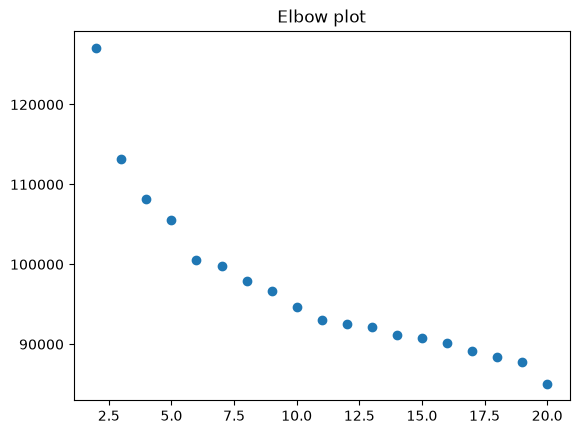

In [5]:

print("Grouping")

dist_matrix_mmap = np.load("dtw_50k_distance_matrix.npy", mmap_mode = "r")

def get_inertia(k):
    kmedoids = KMedoids(
        n_clusters=k, 
        metric = "precomputed", 
        method = "alternate", 
        init = "k-medoids++", 
        random_state = 4
    )
    kmedoids.fit(dist_matrix_mmap)
    print(f"k: {k}")
    return kmedoids.inertia_

k_values = list(range(2, 20 + 1))

# all K-values at the exact same time
inertias = Parallel(n_jobs = 19)(delayed(get_inertia)(k) for k in k_values)

plt.plot(k_values, inertias, "o")
plt.title("Elbow plot")
plt.show()


In [13]:
%%time

optimal_k = 11

def compute_signature(cluster):
    cluster_users = [series_clean[i] for i in range(len(series_clean)) if labels[i] == cluster]
    print(f"cluster: {cluster}")
    
    x_cluster = to_time_series_dataset(cluster_users)
    
    # Calculate the barycenter
    sig = dtw_barycenter_averaging(
        x_cluster,
        max_iter=15,
        metric_params={
            "global_constraint": "sakoe_chiba", 
            "sakoe_chiba_radius": int(window), 
            "itakura_max_slope": float("inf")
        }
    )
    return sig

decay_signatures = Parallel(n_jobs = optimal_k)(delayed(compute_signature)(c) for c in range(optimal_k))


cluster: 0
cluster: 1
cluster: 2
cluster: 3
cluster: 4
cluster: 5
cluster: 6
cluster: 7
cluster: 8
cluster: 9
cluster: 10
CPU times: user 6.13 s, sys: 132 ms, total: 6.26 s
Wall time: 2min 12s


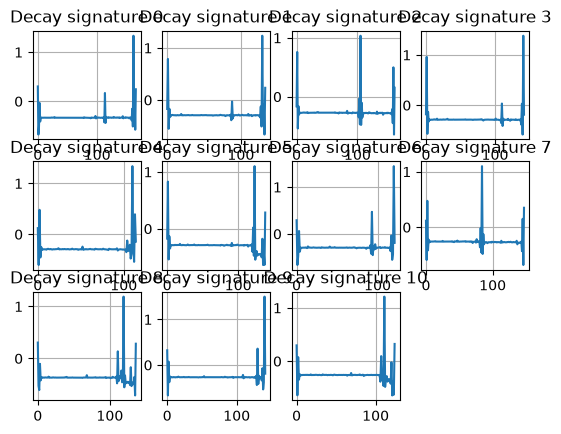

In [ ]:

fig, axes = plt.subplots(3, 4)
axes = axes.flatten()

for i, sig in enumerate(decay_signatures):
    
    axes[i].plot(sig.ravel()) # .ravel() flattens back to 1D for plotting
    axes[i].set_title(f"Decay signature {i}")
    axes[i].grid(True)

# Remove empty subplots
for j in range(len(decay_signatures), len(axes)):
    fig.delaxes(axes[j])
    
plt.show()

In [ ]:

signatures_1d = [np.ascontiguousarray(sig.ravel(), dtype=np.double) for sig in decay_signatures] # .ravel() flattens back to 1D 

df_active = df_tsa.filter(~pl.col("msisdn").is_in(df_ts["msisdn"]))
df_active_ready = df_active.group_by("msisdn").agg(pl.col("tblp_last").cast(pl.Float64).drop_nulls())

msisdns = df_active_ready["msisdn"].to_list()
active_ts_raw = df_active_ready["tblp_last"].to_list()

active_clean = []
valid_msisdns = []

for i, ts in enumerate(active_ts_raw):
    # At least 2 points for standard deviation
    if len(ts) < 2:
        continue
        
    arr = np.array(ts, dtype = np.double)
    std = np.std(arr)
    norm_ts = (arr - np.mean(arr)) / (std if std > 1e-8 else 1.0)
    
    active_clean.append(np.ascontiguousarray(norm_ts))
    valid_msisdns.append(msisdns[i])


def scan_chunk(chunk_of_users):
    results = []
    
    for user_ts in chunk_of_users:
        distances = [
            dtw.distance_fast(user_ts, sig, window = window, penalty = 0.1, use_c = True) 
            for sig in signatures_1d
        ]
        min_dist = min(distances)
        results.append((min_dist, distances.index(min_dist)))
    return results

chunk_size = 25000
chunks = [active_clean[i : i + chunk_size] for i in range(0, len(active_clean), chunk_size)]

chunked_results = Parallel(n_jobs=-1)(delayed(scan_chunk)(chunk) for chunk in chunks)

# List of lists back into a single flat list
scan_results = [res for chunk_res in chunked_results for res in chunk_res]

# Rezip
distances, closest = zip(*scan_results)

df_risk = pl.DataFrame({
    "msisdn": valid_msisdns,
    "closest_signature_id": closest,
    "dtw_risk_score": distances
})

df_risk = df_risk.sort("dtw_risk_score")
display(df_risk.head(30))


# 1m 21.5s to run

/tmp/ipykernel_255692/2174073822.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_active = df_tsa.filter(~pl.col("msisdn").is_in(df_ts["msisdn"]))


msisdn,closest_signature_id,dtw_risk_score
str,i64,f64
"""261378573593""",3,1.571898
"""261329176128""",3,1.574314
"""261376760547""",3,1.576317
"""261379265529""",9,1.580482
"""261373919401""",3,1.582209
"""261377034851""",9,1.583178
"""261328556105""",3,1.58953
"""261321650144""",3,1.593051
"""261327715303""",3,1.593909


/tmp/ipykernel_255692/2451897091.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, i].legend()


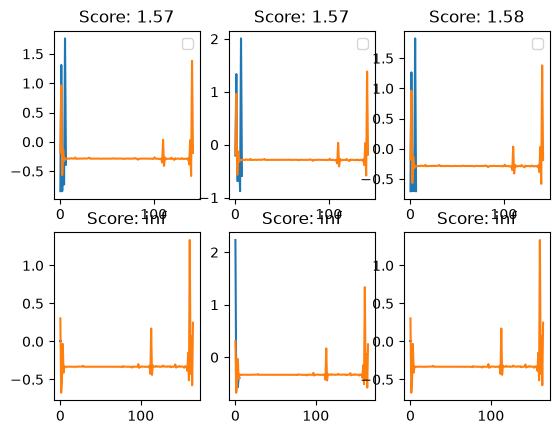

In [22]:

# Active users sequences
user_series_map = dict(zip(valid_msisdns, active_clean))

# Top 3 risky
top_risk = df_risk.head(3).to_dicts()

# Top 3 healthy
low_risk = df_risk.tail(3).to_dicts()

fig, axes = plt.subplots(2, 3)

# Plot high risk
for i, user in enumerate(top_risk):
    msisdn = user["msisdn"]
    sig_id = user["closest_signature_id"]
    score = user["dtw_risk_score"]
    
    user_seq = user_series_map[msisdn]
    sig_seq = signatures_1d[sig_id]
    
    axes[0, i].plot(user_seq)
    axes[0, i].plot(sig_seq)
    axes[0, i].set_title(f"Score: {score:.2f}")
    axes[0, i].legend()

# Plot low risk
for i, user in enumerate(low_risk):
    msisdn = user["msisdn"]
    sig_id = user["closest_signature_id"]
    score = user["dtw_risk_score"]
    
    user_seq = user_series_map[msisdn]
    sig_seq = signatures_1d[sig_id]
    
    axes[1, i].plot(user_seq)
    axes[1, i].plot(sig_seq)
    axes[1, i].set_title(f"Score: {score:.2f}")
    
plt.show()

msisdn,closest_signature_id,dtw_risk_score,actual_last_gap
str,i64,f64,f64
"""261378573593""",3,1.571898,2.0
"""261329176128""",3,1.574314,4.0
"""261376760547""",3,1.576317,7.0
"""261379265529""",9,1.580482,11.0
"""261373919401""",3,1.582209,6.0
"""261377034851""",9,1.583178,4.0
"""261328556105""",3,1.58953,6.0
"""261321650144""",3,1.593051,10.0
"""261327715303""",3,1.593909,21.0


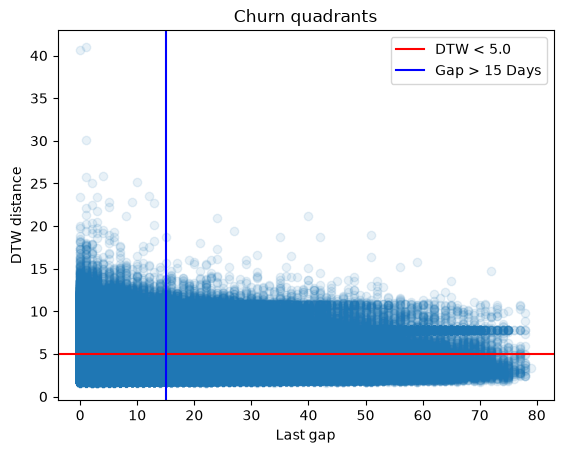

In [27]:

# Take last gap for the valid users
actual_last_gaps = []
for ts in active_ts_raw:
    if len(ts) < 2:
        continue
    actual_last_gaps.append(ts[-1])

df_risk = df_risk.with_columns(pl.Series("actual_last_gap", actual_last_gaps))

# Filter out "inf"
df_plot = df_risk.filter(pl.col("dtw_risk_score").is_finite())

# Nnumpy for fast plotting
x_gaps = df_plot["actual_last_gap"].to_numpy()
y_scores = df_plot["dtw_risk_score"].to_numpy()

display(df_risk.head(30))


plt.scatter(x_gaps, y_scores, alpha = 0.1)

# W to whatever day gap you consider dangerous)
plt.axhline(y = 5.0, color = "red", label = "DTW < 5.0")
plt.axvline(x = 15.0, color = "blue", label = "Gap > 15 Days")

plt.title("Churn quadrants")
plt.xlabel("Last gap")
plt.ylabel("DTW distance")
#plt.ylim(0, 15)
plt.legend()
plt.show()

In [29]:
sum((df_plot["actual_last_gap"] > 15) & (df_plot["dtw_risk_score"] < 5))

195031

In [31]:
sum(((df_plot["actual_last_gap"] < 10) & (df_plot["actual_last_gap"] > 3)) & (df_plot["dtw_risk_score"] < 5))

340857